# 03 - Análise exploratória (EDA)

Notebook responsável pela análise exploratória dos dados limpos em
`data/processed/`: estatísticas descritivas, correlações entre variáveis
climáticas e produção cafeeira, e geração de gráficos exploratórios
(salvos em `figuras/`).

Usa as funções de `src/risco.py`.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/lavras_clima_limpo.csv")
df.shape

(9132, 4)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9132 entries, 0 to 9131
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                9132 non-null   str    
 1   temperature_2m_max  9132 non-null   float64
 2   temperature_2m_min  9132 non-null   float64
 3   precipitation_sum   9132 non-null   float64
dtypes: float64(3), str(1)
memory usage: 374.7 KB


In [3]:
df.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum
0,2000-01-01,21.5,18.7,37.7
1,2000-01-02,20.0,18.8,33.4
2,2000-01-03,21.3,18.4,44.9
3,2000-01-04,20.7,17.9,13.4
4,2000-01-05,26.4,17.1,1.1


In [4]:
df.tail()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum
9127,2024-12-27,22.4,19.1,24.9
9128,2024-12-28,25.7,18.3,12.9
9129,2024-12-29,24.3,17.8,28.7
9130,2024-12-30,26.3,17.4,8.8
9131,2024-12-31,26.4,16.5,6.3


In [5]:
df.describe()

,temperature_2m_max,temperature_2m_min,precipitation_sum
count,9132.000000,9132.000000,9132.000000
mean,25.311947,15.465703,3.203887
std,2.929169,3.141925,6.717872
min,14.300000,3.100000,0.000000
25%,23.400000,13.200000,0.000000
50%,25.500000,16.200000,0.100000
75%,27.300000,18.000000,3.400000
max,36.400000,22.100000,90.600000


## Observações iniciais

1. **Temperatura mínima tem uma cauda fria acentuada**: a média da mínima
   diária é ~15,5 °C (plausível para Lavras, que fica a ~900 m de
   altitude), mas o valor mínimo absoluto é 3,1 °C — indício de eventos
   de geada, relevantes para risco na cafeicultura.
2. **Chuva é muito assimétrica (skewed)**: a mediana de precipitação
   diária é de apenas 0,1 mm, bem abaixo da média de 3,2 mm, e o máximo
   chega a 90,6 mm em um único dia. Isso mostra que a maior parte dos
   dias é seca, com poucos eventos de chuva intensa puxando a média
   para cima — típico do regime de chuvas concentradas em Lavras.

## Índices de risco climático

Usando as funções de `src/risco.py`, calculamos indicadores de risco relevantes para a cafeicultura: dias de geada (leve/severa), dias de chuva excessiva e ocorrências de veranico (sequência de dias secos dentro da estação chuvosa, out-mar).

In [6]:
import sys
sys.path.append("..")

from src.risco import resumo_anual_risco, contar_sequencias_secas

df["time"] = pd.to_datetime(df["time"])

In [7]:
resumo = resumo_anual_risco(df)
resumo

,geada_leve,geada_severa,chuva_excessiva,veranicos
ano,,,,
2000,0,0,1,1
2001,0,0,0,1
2002,0,0,1,2
2003,0,0,0,2
2004,0,0,1,0
2005,0,0,0,2
2006,0,0,0,1
2007,0,0,1,3
2008,0,0,2,0


**Nota sobre geada (limitação de fonte, decisão registrada)**: com o limiar de geada leve (≤3°C), nenhum dia da série é classificado — a mínima absoluta observada na base é 3,1°C. Isso é uma limitação da fonte Open-Meteo (dado de modelo/reanálise em grade, não estação terrestre local), que tende a suavizar extremos.

Investigamos a alternativa: existe uma estação convencional real do INMET em Lavras, no campus da UFLA (código 83687, operando desde 1911, coordenadas quase idênticas às usadas aqui). Não há estação automática do INMET na cidade (a mais próxima é Varginha, ~55 km, desde 2006). O acesso à série histórica da estação 83687, porém, é feito exclusivamente pelo BDMEP do INMET, que exige criar conta — decidimos não seguir por esse caminho nesta fase do projeto. Vale registrar também um alerta da própria UFLA (responsável pela estação, em convênio com o INMET): a série de Lavras tem bastante falha de dados mesmo na fonte original.

**Decisão**: mantemos o Open-Meteo como fonte única nesta fase e tratamos a subestimação de geada como uma limitação conhecida e documentada da pesquisa, não como um bug a corrigir agora. Retomar com dados de estação real (BDMEP ou outra rede) fica como possível trabalho futuro.

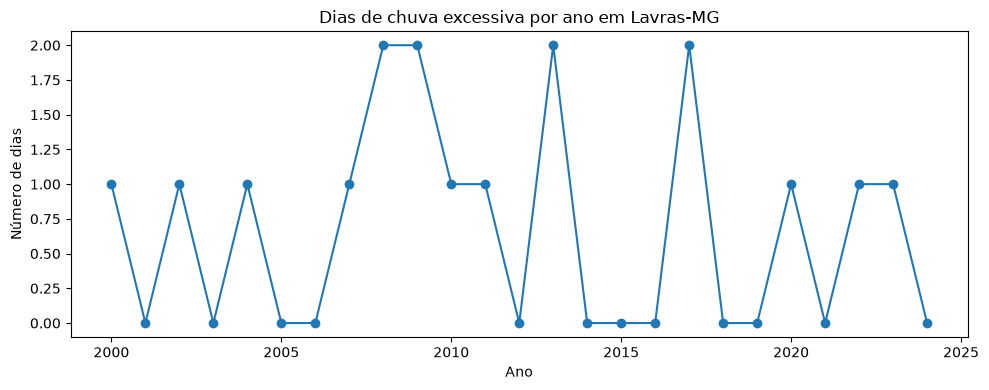

In [8]:
import matplotlib.pyplot as plt

resumo["chuva_excessiva"].plot(marker="o", figsize=(10, 4), title="Dias de chuva excessiva por ano em Lavras-MG")
plt.ylabel("Número de dias")
plt.xlabel("Ano")
plt.tight_layout()
plt.savefig("../figuras/chuva_excessiva_por_ano.png", dpi=150)
plt.show()

### Veranicos

Sequências de pelo menos 10 dias secos consecutivos ocorrendo dentro da estação chuvosa (outubro a março), quando a planta espera chuva regular.

In [9]:
veranicos = contar_sequencias_secas(df)
print("Veranicos detectados:", len(veranicos))
veranicos

Veranicos detectados: 30


,inicio,fim,duracao
0,2000-10-07,2000-10-20,14
1,2001-02-17,2001-03-02,14
2,2002-03-28,2002-04-06,10
3,2002-10-02,2002-10-17,16
4,2003-02-03,2003-02-14,12
5,2003-10-12,2003-10-21,10
6,2005-03-26,2005-04-05,11
7,2005-10-08,2005-10-18,11
8,2006-01-09,2006-01-25,17
9,2007-02-28,2007-03-16,17


## Clima x Produção cafeeira

Pergunta de pesquisa central do projeto: existe correlação histórica entre
os riscos climáticos (geada, chuva excessiva, veranico) e a produtividade
do café em Lavras-MG? Juntamos o resumo anual de risco (`resumo`, acima)
com a série anual de produção do IBGE/SIDRA (`data/processed/lavras_producao_cafe_limpo.csv`)
para investigar.

In [10]:
df_cafe = pd.read_csv("../data/processed/lavras_producao_cafe_limpo.csv")
df_cafe = df_cafe.set_index("ano")

clima_x_producao = resumo.join(df_cafe, how="inner")
clima_x_producao

,geada_leve,geada_severa,chuva_excessiva,veranicos,quantidade_produzida_t,rendimento_medio_kg_ha,area_colhida_ha
ano,,,,,,,
2000,0,0,1,1,7210,2060,3500
2001,0,0,0,1,7560,2160,3500
2002,0,0,1,2,3780,1080,3500
2003,0,0,0,2,3780,1080,3500
2004,0,0,1,0,4440,1200,3700
2005,0,0,0,2,4440,1200,3700
2006,0,0,0,1,4920,1200,4100
2007,0,0,1,3,2952,720,4100
2008,0,0,2,0,3825,900,4250


### Correlação

Usamos correlação de Pearson entre os 4 indicadores de risco climático e
as 3 variáveis de produção. **Ressalva importante**: a série tem apenas
25 anos (um ponto por ano), uma amostra pequena para conclusões causais —
tratamos os resultados como indícios exploratórios, não como prova
estatística robusta.

In [11]:
colunas_risco = ["geada_leve", "geada_severa", "chuva_excessiva", "veranicos"]
colunas_producao = ["area_colhida_ha", "quantidade_produzida_t", "rendimento_medio_kg_ha"]

corr_cruzada = clima_x_producao.corr(method="pearson").loc[colunas_risco, colunas_producao]
corr_cruzada

,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha
geada_leve,NaN,NaN,NaN
geada_severa,NaN,NaN,NaN
chuva_excessiva,-0.066706,-0.107639,-0.048883
veranicos,-0.230010,-0.209704,-0.062119


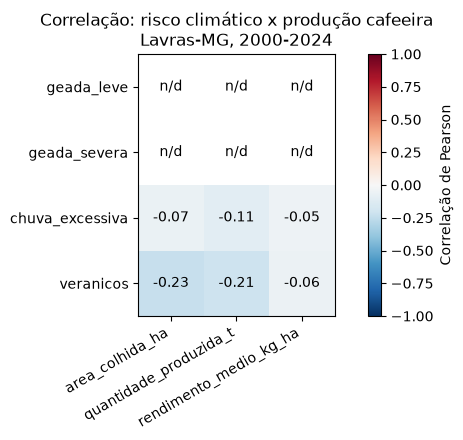

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(corr_cruzada, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(colunas_producao)), labels=colunas_producao, rotation=30, ha="right")
ax.set_yticks(range(len(colunas_risco)), labels=colunas_risco)

for i in range(len(colunas_risco)):
    for j in range(len(colunas_producao)):
        valor = corr_cruzada.iloc[i, j]
        texto = "n/d" if pd.isna(valor) else f"{valor:.2f}"
        ax.text(j, i, texto, ha="center", va="center", color="black")

ax.set_title("Correlação: risco climático x produção cafeeira\nLavras-MG, 2000-2024")
fig.colorbar(im, ax=ax, label="Correlação de Pearson")
plt.tight_layout()
plt.savefig("../figuras/correlacao_risco_producao.png", dpi=150, bbox_inches="tight")
plt.show()

### Leitura dos resultados

- **Geada**: correlação não calculável (`n/d`) — consequência direta da
  limitação já registrada acima (nenhum dia da série cai no limiar de
  geada). A pergunta "geada afeta a produção?" segue em aberto nesta fase.
- **Todas as correlações observadas são fracas** (|r| < 0,25). O
  indicador mais forte é veranico x área colhida (r ≈ -0,23), ainda
  assim longe de indicar uma relação linear robusta.
- **Cuidado com `area_colhida_ha`**: a série cresce de forma quase
  monotônica ao longo dos 25 anos (3.500 ha em 2000 → 5.020 ha em 2024),
  provavelmente refletindo expansão econômica da cafeicultura na região,
  não um sinal climático. Correlações envolvendo essa coluna podem ser
  espúrias por essa tendência temporal compartilhada.
- **`rendimento_medio_kg_ha`** (produtividade por área, menos afetado
  pela expansão de área) é o proxy mais limpo de produtividade — e é
  justamente onde as correlações são mais próximas de zero
  (chuva excessiva: -0,05; veranico: -0,06).

**Conclusão desta fase**: com os índices e a fonte de dados atuais, não
encontramos evidência de relação linear forte entre risco climático anual
e produtividade do café em Lavras-MG. Isso não significa que a relação
não exista — pode ser não linear, defasada (ex.: geada de um ano afeta a
safra do ano seguinte), ou exigir uma amostra maior/mais granular do que
25 pontos anuais. Fica como direção de trabalho futuro.